# Le Cun et al. (1989) rebuilt in Keras, compared with Chollet (2021)

This notebook runs every experiment, in order, from raw data to the final tables and figures.
Every reported number is computed here.

**Sources of the code.** The baseline network is the Keras example *Simple MNIST convnet* by
Chollet (2021). The reconstruction modifies that code to follow Le Cun et al. (1989), "Handwritten
digit recognition with a back-propagation network", *Advances in Neural Information Processing
Systems 2*, pp. 396-404. Both sources are cited at the point of use. The reusable code (custom
layers, models, training loop, statistics, figures) lives in the package `src/lecun1989/`.

**Protocol.** Every design decision for the reconstruction (optimiser, learning rate, dropout
substitute) is made on the validation set. The test set is used only in Section 4, once per run,
after all choices are fixed.

| Section | Content |
|---|---|
| 1 | The MNIST dataset |
| 2 | Both models, and a check of the reconstruction against the paper's published totals |
| 3 | Model selection on the validation set |
| 4 | Final experiments: four configurations, five seeds each |
| 5 | Statistical comparison |
| 6 | Learning behaviour and error analysis |
| 7 | Export of tables, figures and the graphical abstract |

In [1]:
# Setup. The TensorFlow backend is the one Chollet (2021) was written for.
import os

os.environ.setdefault("KERAS_BACKEND", "tensorflow")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import json
import warnings
from pathlib import Path

# Keep the executed notebook readable: silence library deprecation notices.
warnings.filterwarnings("ignore")

import keras
import numpy as np
import pandas as pd
from IPython.display import Image, display

import lecun1989
from lecun1989 import figures as F
from lecun1989.data import class_counts, load_mnist, load_raw
from lecun1989.layers import LECUN_1989_TABLE1
from lecun1989.models import build_chollet_2021, build_lecun_1989, network_accounting
from lecun1989.stats import confusion_matrix, mcnemar_exact, mean_ci
from lecun1989.training import CHOLLET_RECIPE, LECUN_RECIPE, environment, train_and_evaluate

# The project root is located from the installed package, so the notebook runs
# from any working directory (install with `pip install -e .`).
ROOT = Path(lecun1989.__file__).resolve().parents[2]
assert (ROOT / "pyproject.toml").exists(), "install the package with `pip install -e .`"

# LECUN1989_SMOKE=1 runs every cell with 1 epoch and 2 seeds into a scratch
# folder, to check the notebook end to end in minutes. It is off for real runs.
SMOKE = os.environ.get("LECUN1989_SMOKE") == "1"
OUT = Path(os.environ.get("LECUN1989_OUT", ROOT / "results"))
FIG, TAB, MET = OUT / "figures", OUT / "tables", OUT / "metrics"
for d in (FIG, TAB, MET):
    d.mkdir(parents=True, exist_ok=True)

SEEDS = [0, 1, 2, 3, 4]
if SMOKE:
    SEEDS = [0, 1]
    CHOLLET_RECIPE = CHOLLET_RECIPE.with_(epochs=1)
    LECUN_RECIPE = LECUN_RECIPE.with_(epochs=1)
F.set_style()
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

ENV = environment()
(MET / "environment.json").write_text(json.dumps(ENV, indent=2))
for k, v in ENV.items():
    print(f"{k:>14}: {v}")

        python: 3.12.13
      platform: Darwin 27.0.0 (arm64)
     processor: arm
  logical_cpus: 10
         keras: 3.15.1
       backend: tensorflow
         numpy: 2.5.3
    tensorflow: 2.21.0
       devices: ['CPU']


## 1 The MNIST dataset

In [2]:
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = load_raw()
print("training images:", x_train_raw.shape, x_train_raw.dtype)
print("test images:    ", x_test_raw.shape, x_test_raw.dtype)
print("pixel range:    ", x_train_raw.min(), "to", x_train_raw.max())
print("share of pixels that are exactly 0 (background): "
      f"{100 * np.mean(x_train_raw == 0):.1f}%")

# Where does the ink sit? MNIST centres each digit by centre of mass in a
# 28x28 frame, so the outer rows and columns should be almost always blank.
ink = (x_train_raw > 0).any(axis=0)
rows, cols = np.flatnonzero(ink.any(axis=1)), np.flatnonzero(ink.any(axis=0))
print(f"rows ever inked: {rows.min()}-{rows.max()}, columns ever inked: {cols.min()}-{cols.max()}")
bbox = np.array([(np.ptp(np.flatnonzero(im.any(axis=1))) + 1, np.ptp(np.flatnonzero(im.any(axis=0))) + 1)
                 for im in (x_train_raw[:10000] > 0)])
print(f"per-image ink bounding box (first 10,000): median height {np.median(bbox[:, 0]):.0f}px, "
      f"median width {np.median(bbox[:, 1]):.0f}px, max {bbox.max()}px")

training images: (60000, 28, 28) uint8
test images:     (10000, 28, 28) uint8
pixel range:     0 to 255
share of pixels that are exactly 0 (background): 80.9%
rows ever inked: 0-27, columns ever inked: 0-27


per-image ink bounding box (first 10,000): median height 20px, median width 16px, max 20px


In [3]:
# The partition used by every model: Keras' validation_split=0.1 takes the
# LAST 10% of the training arrays, so Chollet (2021) trains on images 0-53,999.
data = load_mnist("unit", "onehot")
split_table = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "images": [len(data.train), len(data.val), len(data.test)],
        "source": ["MNIST training set, images 0-53,999", "MNIST training set, images 54,000-59,999",
                   "MNIST test set"],
    }
)
counts = pd.DataFrame(
    {"digit": range(10), "train": class_counts(data.train.labels),
     "validation": class_counts(data.val.labels), "test": class_counts(data.test.labels)}
)
counts["test_share_%"] = 100 * counts["test"] / counts["test"].sum()
split_table.to_csv(TAB / "t01_partition.csv", index=False)
counts.to_csv(TAB / "t01_class_counts.csv", index=False)
display(split_table)
display(counts.round(2))
print(f"largest / smallest class in training split: "
      f"{counts['train'].max() / counts['train'].min():.2f}x")

,split,images,source
0,train,54000,"MNIST training set, images 0-53,999"
1,validation,6000,"MNIST training set, images 54,000-59,999"
2,test,10000,MNIST test set


,digit,train,validation,test,test_share_%
0,0,5336,587,980,9.80
1,1,6112,630,1135,11.35
2,2,5358,600,1032,10.32
3,3,5504,627,1010,10.10
4,4,5247,595,982,9.82
5,5,4872,549,892,8.92
6,6,5347,571,958,9.58
7,7,5597,668,1028,10.28
8,8,5254,597,974,9.74
9,9,5373,576,1009,10.09


largest / smallest class in training split: 1.25x


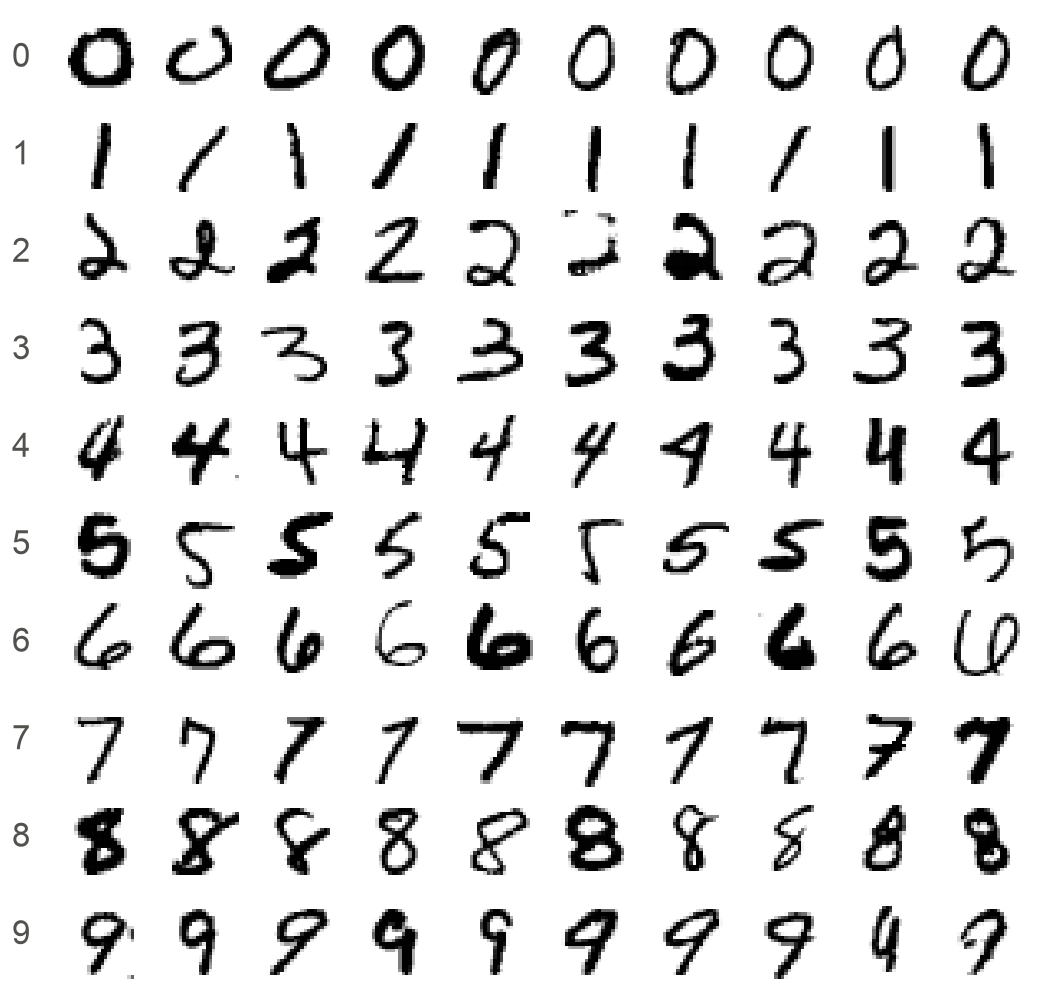

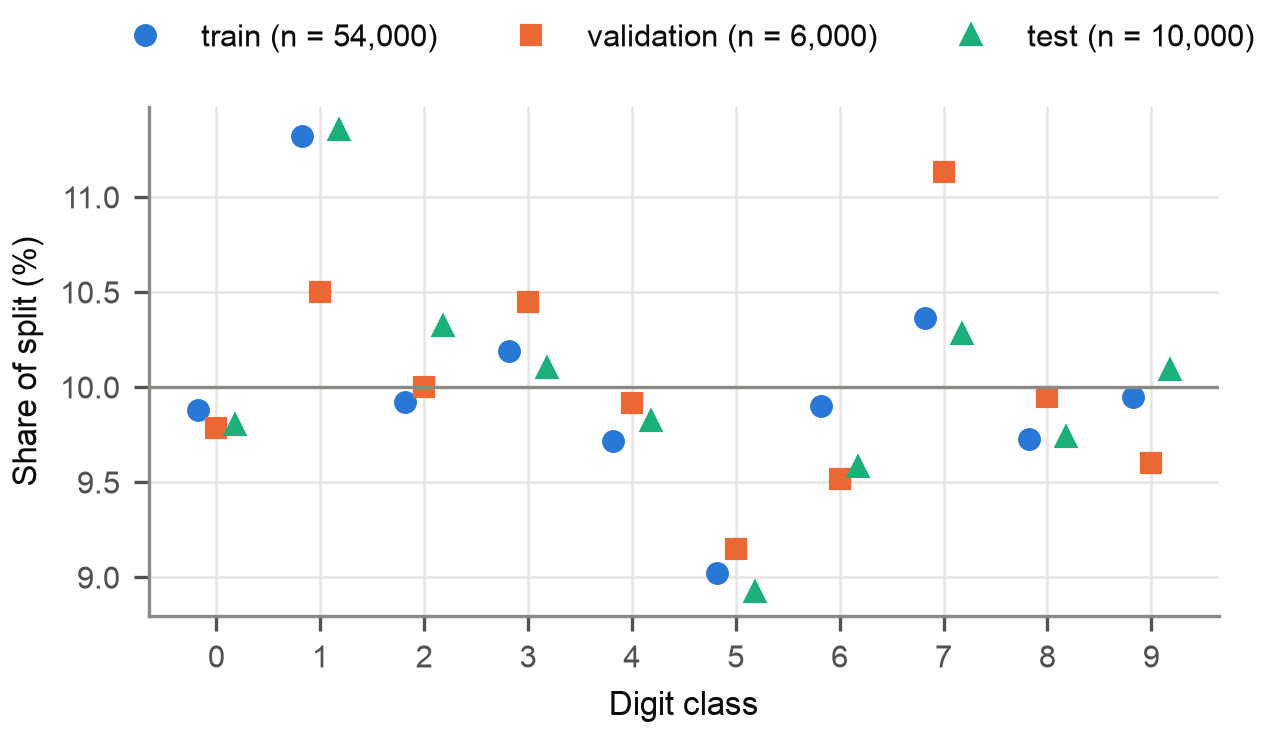

In [4]:
F.save(F.mnist_samples(x_test_raw, y_test_raw, per_class=10), FIG / "fig01_mnist_samples.png")
F.save(F.class_distribution(counts["train"], counts["validation"], counts["test"]),
       FIG / "fig01b_class_distribution.png")
display(Image(FIG / "fig01_mnist_samples.png", width=330))
display(Image(FIG / "fig01b_class_distribution.png", width=520))

## 2 The two models

### 2.1 Chollet (2021)
The architecture below is the Keras example unchanged (`build_chollet_2021` in `src/lecun1989/models.py`).

In [5]:
keras.utils.set_random_seed(0)
chollet = build_chollet_2021()
chollet.summary()

Model: "chollet_2021"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

### 2.2 Le Cun et al. (1989), reconstructed

Chollet's `Sequential` model is modified layer by layer to follow pp. 399-402 of the paper. The two
layers Keras lacks are implemented in `src/lecun1989/layers.py`: `TrainableSubsampling2D` (H2, H4)
and `ConnectionTableConv2D` (H3, with the connection scheme of Table 1, p. 400).

In [6]:
keras.utils.set_random_seed(0)
lecun = build_lecun_1989()
lecun.summary()

print("Table 1 (rows: H2 maps, columns: H3 maps):")
print(pd.DataFrame(LECUN_1989_TABLE1, index=[f"H2.{i + 1}" for i in range(4)],
                   columns=[f"H3.{j + 1}" for j in range(12)]).replace({1: "X", 0: "."}).to_string())

Model: "lecun_1989"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ H1 (Conv2D)                     │ (None, 24, 24, 4)      │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ H2 (TrainableSubsampling2D)     │ (None, 12, 12, 4)      │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ H3 (ConnectionTableConv2D)      │ (None, 8, 8, 12)       │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ H4 (TrainableSubsampling2D)     │ (None, 4, 4, 12)       │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,930 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,578 (10.07 KB)

 Trainable params: 2,578 (10.07 KB)

 Non-trainable params: 0 (0.00 B)

Table 1 (rows: H2 maps, columns: H3 maps):
     H3.1 H3.2 H3.3 H3.4 H3.5 H3.6 H3.7 H3.8 H3.9 H3.10 H3.11 H3.12
H2.1    X    X    X    .    X    X    .    .    .     .     .     .
H2.2    .    X    X    X    X    X    .    .    .     .     .     .
H2.3    .    .    .    .    .    .    X    X    X     .     X     X
H2.4    .    .    .    .    .    .    .    X    X     X     X     X


**Check against the paper.** Le Cun et al. (1989, p. 402) state that the network "has 4635 units,
98442 connections, and 2578 independent parameters". The accounting below derives all three numbers
from the Keras model itself. Matching all three confirms the layer sizes, kernels, weight and bias
sharing and the number of H2-H3 connections. The totals do not depend on which 20 of the 48 possible
connections are present, so the pattern of Table 1 is checked against the paper by a separate unit test.

In [7]:
acc = network_accounting(lecun)
check = pd.DataFrame(
    {
        "quantity": ["units (incl. bias unit)", "connections", "independent parameters"],
        "Le Cun et al. (1989, p. 402)": [4635, 98442, 2578],
        "this reconstruction": [acc["units_including_bias_unit"], acc["connections"], acc["parameters"]],
    }
)
check["match"] = check.iloc[:, 1] == check.iloc[:, 2]
per_layer = pd.DataFrame(
    {
        "layer": list(acc["connections_per_layer"]),
        "units": [acc["units_per_layer"][k] for k in acc["connections_per_layer"]],
        "connections": list(acc["connections_per_layer"].values()),
        "parameters": [lecun.get_layer(k).count_params() for k in acc["connections_per_layer"]],
    }
)
check.to_csv(TAB / "t02_paper_check.csv", index=False)
per_layer.to_csv(TAB / "t02_per_layer.csv", index=False)
display(check)
display(per_layer)
assert check["match"].all(), "reconstruction does not reproduce the published totals"

,quantity,"Le Cun et al. (1989, p. 402)",this reconstruction,match
0,units (incl. bias unit),4635,4635,True
1,connections,98442,98442,True
2,independent parameters,2578,2578,True


,layer,units,connections,parameters
0,H1,2304,59904,104
1,H2,576,2880,8
2,H3,768,32768,512
3,H4,192,960,24
4,output,10,1930,1930


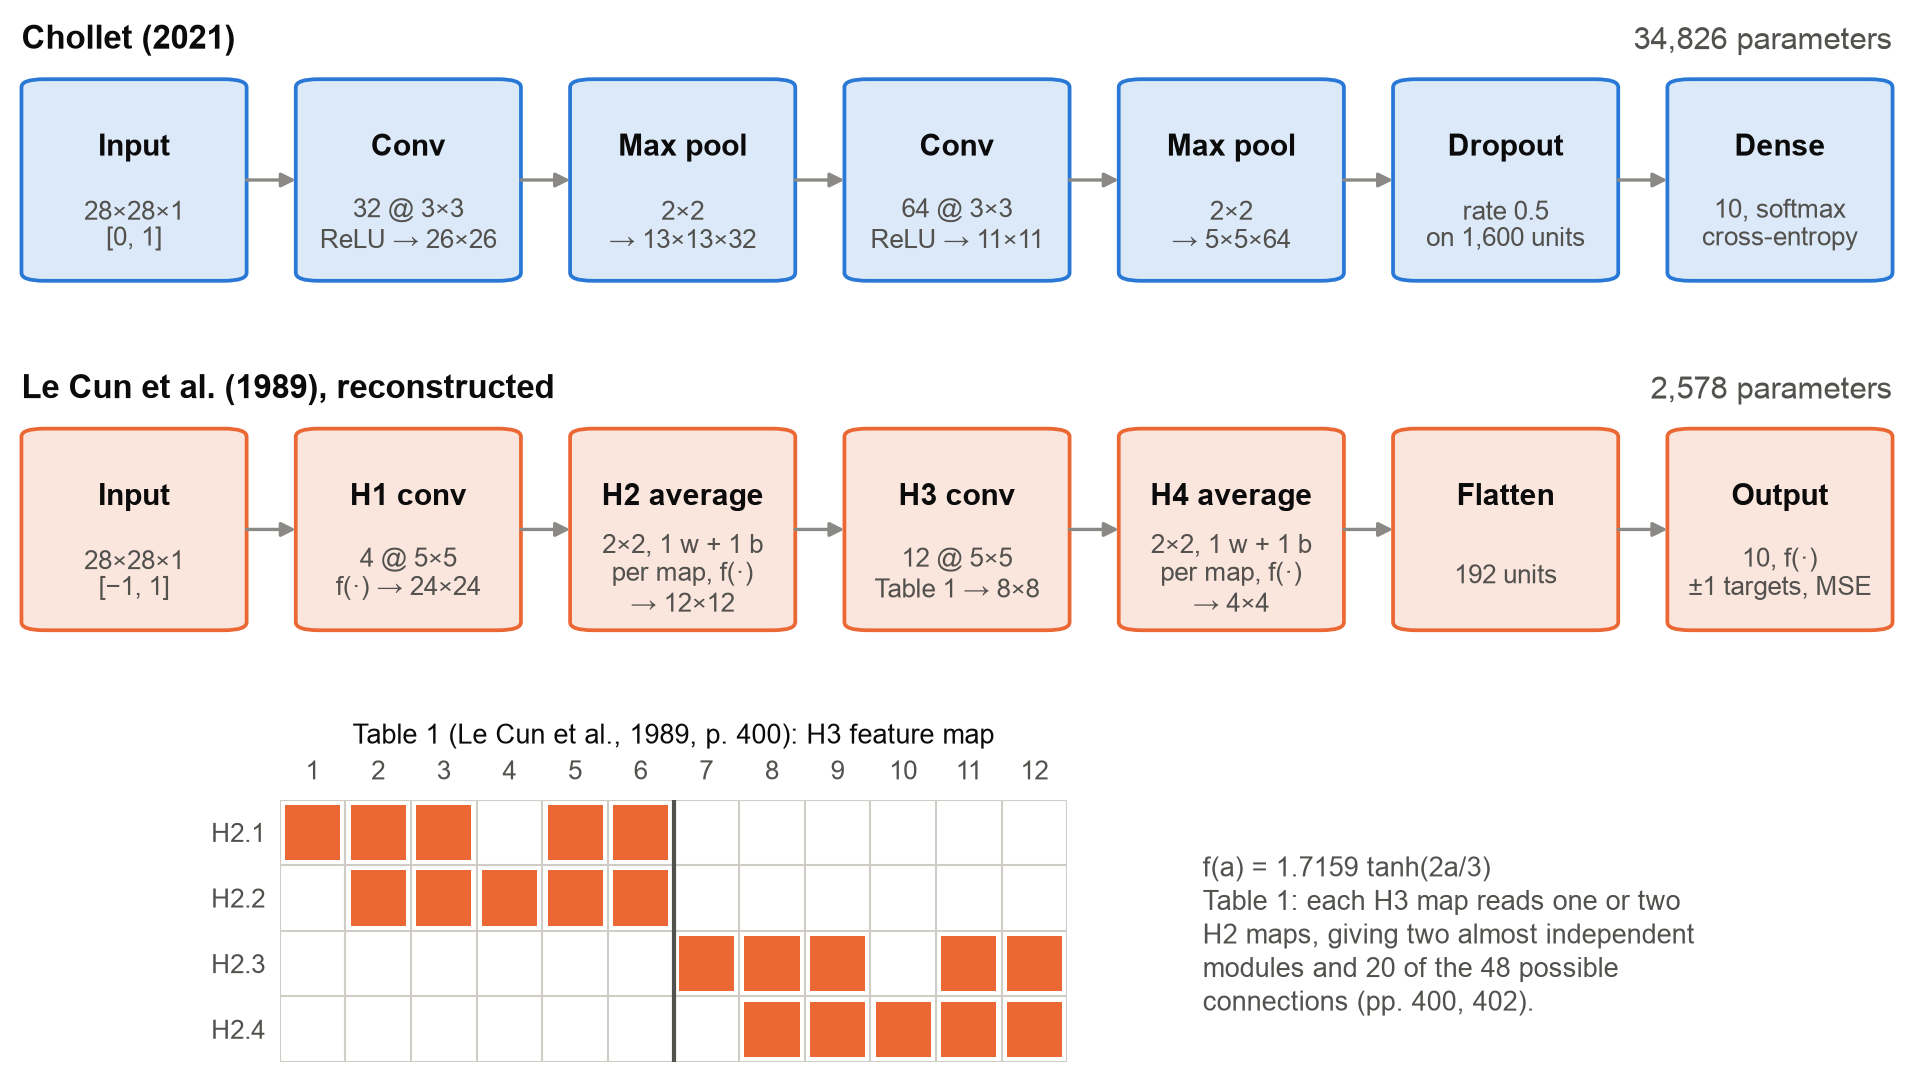

In [8]:
F.save(F.architecture_diagram(), FIG / "fig02_architectures.png")
display(Image(FIG / "fig02_architectures.png", width=620))

## 3 Model selection on the validation set

Two things about the reconstruction cannot be read off the paper and are chosen here, on the 6,000
validation images only.

**Optimiser.** The paper used "a second-order version of back-propagation" (p. 402), which Keras does
not provide. Two substitutes are compared: plain stochastic gradient descent, the first-order
algorithm the 1989 method extends, at four learning rates; and RMSprop, which, like a diagonal
second-order method, gives every weight its own step size. The selection rule, fixed in advance,
is the highest validation accuracy after the 30 epochs the paper used.

**A dropout substitute for Table 1.** A natural modern alternative to the sparse H2-H3 connections
is to connect everything and regularise with dropout. H3 is therefore connected to all four H2 maps, and dropout is applied to
the H2 maps. `SpatialDropout2D` removes whole maps, the same granularity at which Table 1 removes
connections; ordinary `Dropout` removes single units. Both are tried at two rates, alongside a fully
connected H3 without dropout as a reference.

In [9]:
selection_rows = []

def select(label, build, recipe, group):
    r = train_and_evaluate(build, recipe, seed=0, evaluate_test=False)
    best = int(np.argmax(r.history["val_accuracy"])) + 1
    row = {"group": group, "configuration": label, "parameters": r.parameters,
           "val_accuracy_final": r.val_accuracy,
           "val_accuracy_best": max(r.history["val_accuracy"]), "best_epoch": best,
           "train_loss_final": r.history["loss"][-1], "train_seconds": r.train_seconds}
    selection_rows.append(row)
    print(f"{label:<42} final val acc {r.val_accuracy:.4f}  "
          f"(best {row['val_accuracy_best']:.4f} @ epoch {best}, {r.train_seconds:.0f}s)")
    return r

optimiser_grid = [
    ("SGD, learning rate 0.01", LECUN_RECIPE.with_(optimizer="sgd", learning_rate=0.01)),
    ("SGD, learning rate 0.03", LECUN_RECIPE.with_(optimizer="sgd", learning_rate=0.03)),
    ("SGD, learning rate 0.1", LECUN_RECIPE.with_(optimizer="sgd", learning_rate=0.1)),
    ("SGD, learning rate 0.3", LECUN_RECIPE.with_(optimizer="sgd", learning_rate=0.3)),
    ("RMSprop, learning rate 0.001", LECUN_RECIPE.with_(optimizer="rmsprop", learning_rate=0.001)),
]
opt_results = {label: select(label, build_lecun_1989, rec, "optimiser") for label, rec in optimiser_grid}

best_opt_label = max(opt_results, key=lambda k: opt_results[k].val_accuracy)
LECUN_FINAL = dict(optimiser_grid)[best_opt_label]
print(f"\nselected: {best_opt_label}")

SGD, learning rate 0.01                    final val acc 0.9742  (best 0.9743 @ epoch 29, 112s)


SGD, learning rate 0.03                    final val acc 0.9817  (best 0.9817 @ epoch 30, 118s)


SGD, learning rate 0.1                     final val acc 0.9847  (best 0.9847 @ epoch 29, 113s)


SGD, learning rate 0.3                     final val acc 0.9820  (best 0.9825 @ epoch 12, 112s)


RMSprop, learning rate 0.001               final val acc 0.9855  (best 0.9855 @ epoch 22, 115s)

selected: RMSprop, learning rate 0.001


In [10]:
dropout_grid = [
    ("Full H2-H3 connections, no dropout", dict(h3="dense", h3_dropout=0.0)),
    ("Full + SpatialDropout2D 0.25", dict(h3="dense", h3_dropout=0.25, dropout_kind="spatial")),
    ("Full + SpatialDropout2D 0.5", dict(h3="dense", h3_dropout=0.5, dropout_kind="spatial")),
    ("Full + Dropout 0.25", dict(h3="dense", h3_dropout=0.25, dropout_kind="standard")),
    ("Full + Dropout 0.5", dict(h3="dense", h3_dropout=0.5, dropout_kind="standard")),
]
drop_results = {
    label: select(label, lambda kw=kw: build_lecun_1989(**kw), LECUN_FINAL, "dropout")
    for label, kw in dropout_grid
}
candidates = {label: drop_results[label] for label, kw in dropout_grid if kw.get("h3_dropout", 0) > 0}
best_drop_label = max(candidates, key=lambda k: candidates[k].val_accuracy)
DROPOUT_KW = dict(dropout_grid)[best_drop_label]
print(f"\nselected dropout substitute: {best_drop_label}")
print(f"Table 1 reconstruction at the same settings (seed 0): "
      f"{opt_results[best_opt_label].val_accuracy:.4f}")

selection = pd.DataFrame(selection_rows)
selection.to_csv(TAB / "t03_model_selection.csv", index=False)
display(selection.round(4))

Full H2-H3 connections, no dropout         final val acc 0.9842  (best 0.9842 @ epoch 29, 113s)


Full + SpatialDropout2D 0.25               final val acc 0.9797  (best 0.9797 @ epoch 30, 122s)


Full + SpatialDropout2D 0.5                final val acc 0.9777  (best 0.9785 @ epoch 23, 121s)


Full + Dropout 0.25                        final val acc 0.9820  (best 0.9828 @ epoch 26, 132s)


Full + Dropout 0.5                         final val acc 0.9773  (best 0.9777 @ epoch 18, 125s)

selected dropout substitute: Full + Dropout 0.25
Table 1 reconstruction at the same settings (seed 0): 0.9855


,group,configuration,parameters,val_accuracy_final,val_accuracy_best,best_epoch,train_loss_final,train_seconds
0,optimiser,"SGD, learning rate 0.01",2578,0.9742,0.9743,29,0.0567,112.4243
1,optimiser,"SGD, learning rate 0.03",2578,0.9817,0.9817,30,0.0486,117.6154
2,optimiser,"SGD, learning rate 0.1",2578,0.9847,0.9847,29,0.0451,112.6211
3,optimiser,"SGD, learning rate 0.3",2578,0.9820,0.9825,12,0.0411,111.6889
4,optimiser,"RMSprop, learning rate 0.001",2578,0.9855,0.9855,22,0.0439,114.5606
5,dropout,"Full H2-H3 connections, no dropout",3278,0.9842,0.9842,29,0.0387,112.7900
6,dropout,Full + SpatialDropout2D 0.25,3278,0.9797,0.9797,30,0.0543,122.0999
7,dropout,Full + SpatialDropout2D 0.5,3278,0.9777,0.9785,23,0.0753,121.1319
8,dropout,Full + Dropout 0.25,3278,0.9820,0.9828,26,0.0540,131.9508
9,dropout,Full + Dropout 0.5,3278,0.9773,0.9777,18,0.0684,124.7644


### Parameters of the three networks

Chollet (2021), the paper, and this implementation side by side.

In [11]:
opt_name = {"sgd": "SGD", "rmsprop": "RMSprop", "adam": "Adam"}[LECUN_FINAL.optimizer]
params_table = pd.DataFrame(
    [
        ("Data set", "MNIST", "U.S. Postal Service zip codes + printed digits (p. 397)", "MNIST"),
        ("Training / validation / test", "54,000 / 6,000 / 10,000", "9,840 / none reported / 2,707 (p. 397)",
         "54,000 / 6,000 / 10,000"),
        ("Input", "28×28, scaled to [0, 1]", "16×16 digit in a 28×28 plane, [−1, 1] (pp. 398, 400)",
         "28×28, scaled to [−1, 1]"),
        ("Hidden layers", "2 conv + 2 max pool", "4: H1-H4 (p. 400)", "4: H1-H4"),
        ("Feature maps per layer", "32, 64", "4, 4, 12, 12 (pp. 400-402)", "4, 4, 12, 12"),
        ("Filter size", "3×3", "5×5 conv, 2×2 averaging (p. 400)", "5×5 conv, 2×2 averaging"),
        ("Pooling", "Max, 2×2", "Trainable averaging, 2×2 (p. 400)", "Trainable averaging, 2×2"),
        ("H2-H3 connections", "n/a", "Table 1, 20 of 48 (p. 400)", "Table 1, exact"),
        ("Activation", "ReLU; softmax output", "Squashing function (p. 399)", "1.7159 tanh(2a/3)"),
        ("Targets and loss", "One-hot, cross-entropy", "±1 targets (p. 399), MSE (p. 402)", "±1 targets, MSE"),
        ("Regularisation", "Dropout 0.5", "Weight sharing, sparse connections", "Weight sharing, Table 1"),
        ("Free parameters", "34,826", "2,578 (p. 402)", f"{lecun.count_params():,}"),
        ("Optimiser", "Adam, learning rate 0.001", "Second-order back-propagation (p. 402)",
         f"{opt_name}, learning rate {LECUN_FINAL.learning_rate:g}"),
        ("Batch size", "128", "Not stated", str(LECUN_FINAL.batch_size)),
        ("Epochs", "15", "30 passes (p. 402)", str(LECUN_FINAL.epochs)),
    ],
    columns=["Aspect", "Chollet (2021)", "Le Cun et al. (1989)", "This implementation"],
)
params_table.to_csv(TAB / "t04_parameters.csv", index=False)
display(params_table)

,Aspect,Chollet (2021),Le Cun et al. (1989),This implementation
0,Data set,MNIST,U.S. Postal Service zip codes + printed digits...,MNIST
1,Training / validation / test,"54,000 / 6,000 / 10,000","9,840 / none reported / 2,707 (p. 397)","54,000 / 6,000 / 10,000"
2,Input,"28×28, scaled to [0, 1]","16×16 digit in a 28×28 plane, [−1, 1] (pp. 398...","28×28, scaled to [−1, 1]"
3,Hidden layers,2 conv + 2 max pool,4: H1-H4 (p. 400),4: H1-H4
4,Feature maps per layer,"32, 64","4, 4, 12, 12 (pp. 400-402)","4, 4, 12, 12"
5,Filter size,3×3,"5×5 conv, 2×2 averaging (p. 400)","5×5 conv, 2×2 averaging"
6,Pooling,"Max, 2×2","Trainable averaging, 2×2 (p. 400)","Trainable averaging, 2×2"
7,H2-H3 connections,n/a,"Table 1, 20 of 48 (p. 400)","Table 1, exact"
8,Activation,ReLU; softmax output,Squashing function (p. 399),1.7159 tanh(2a/3)
9,Targets and loss,"One-hot, cross-entropy","±1 targets (p. 399), MSE (p. 402)","±1 targets, MSE"


## 4 Final experiments

Four configurations, each trained with five seeds and evaluated once on the test set:

| Key | Network | Training recipe | Why it is here |
|---|---|---|---|
| `chollet` | Chollet (2021) | Chollet (2021) | the modern baseline |
| `lecun` | 1989 network with Table 1 | 1989 recipe (selected optimiser) | the reconstruction |
| `lecun_dropout` | 1989 network, full H2-H3 + selected dropout | 1989 recipe | tests dropout as a substitute for Table 1 |
| `lecun_chollet_recipe` | 1989 network with Table 1, softmax output | Chollet (2021) | separates the effect of the network from the effect of the training recipe |

Runs are interleaved by seed (all four configurations for seed 0, then seed 1, ...) so that any drift in
machine load affects every configuration comparably. Training time is the wall-clock duration of
`model.fit`, which, as in Chollet's example, includes the validation pass after each epoch. Inference
time is the median of five passes over the 10,000 test images (batches of 1,024, after a warm-up).
Test accuracy is computed from the predicted labels; training accuracy is measured after training in
inference mode, so that it is comparable with validation accuracy.

In [12]:
CONFIGS = {
    "chollet": (build_chollet_2021, CHOLLET_RECIPE),
    "lecun": (build_lecun_1989, LECUN_FINAL),
    "lecun_dropout": (lambda: build_lecun_1989(**DROPOUT_KW), LECUN_FINAL),
    "lecun_chollet_recipe": (lambda: build_lecun_1989(head="softmax"), CHOLLET_RECIPE),
}

runs = {key: [] for key in CONFIGS}
for seed in SEEDS:
    for key, (build, recipe) in CONFIGS.items():
        verbose = 2 if (seed == 0 and key in {"chollet", "lecun"}) else 0
        if verbose:
            print(f"\n--- {key}, seed {seed}: full training log ---")
        r = train_and_evaluate(build, recipe, seed=seed, evaluate_test=True, verbose=verbose)
        runs[key].append(r)
        print(f"seed {seed}  {key:<22} test acc {r.test_accuracy:.4f}  test loss {r.test_loss:.4f}  "
              f"train {r.train_seconds:6.1f}s  ({np.mean(r.epoch_seconds):.2f}s/epoch)")
        if seed == 0:
            r.model.save(MET / f"model_{key}_seed0.keras")


--- chollet, seed 0: full training log ---


Epoch 1/15


422/422 - 6s - 15ms/step - accuracy: 0.8893 - loss: 0.3616 - val_accuracy: 0.9778 - val_loss: 0.0836


Epoch 2/15


422/422 - 5s - 13ms/step - accuracy: 0.9679 - loss: 0.1071 - val_accuracy: 0.9845 - val_loss: 0.0579


...

seed 3  lecun_chollet_recipe   test acc 0.9832  test loss 0.0502  train   32.8s  (2.18s/epoch)


seed 4  chollet                test acc 0.9913  test loss 0.0252  train   82.7s  (5.51s/epoch)


seed 4  lecun                  test acc 0.9796  test loss 0.0431  train  109.7s  (3.65s/epoch)


seed 4  lecun_dropout          test acc 0.9787  test loss 0.0434  train  115.0s  (3.83s/epoch)


seed 4  lecun_chollet_recipe   test acc 0.9825  test loss 0.0528  train   32.1s  (2.14s/epoch)


In [13]:
per_run = pd.DataFrame([r.summary() | {"config": key} for key, rs in runs.items() for r in rs])
per_run.to_csv(TAB / "t05_all_runs.csv", index=False)
for key, rs in runs.items():
    for r in rs:
        (MET / f"history_{key}_seed{r.seed}.json").write_text(json.dumps(
            {"history": r.history, "epoch_seconds": r.epoch_seconds, "recipe": r.recipe}, indent=1))
        np.save(MET / f"pred_{key}_seed{r.seed}.npy", r.test_predictions)
display(per_run.drop(columns=["recipe"]).round(4))

,model,seed,parameters,train_seconds,seconds_per_epoch,train_accuracy,val_accuracy,test_loss,test_accuracy,test_error_pct,inference_ms_per_image,config
0,chollet_2021,0,34826,84.1170,5.6032,0.9961,0.9922,0.0224,0.9923,0.77,0.0293,chollet
1,chollet_2021,1,34826,80.0341,5.3335,0.9957,0.9930,0.0264,0.9907,0.93,0.0284,chollet
2,chollet_2021,2,34826,81.8202,5.4521,0.9955,0.9920,0.0258,0.9926,0.74,0.0277,chollet
3,chollet_2021,3,34826,84.7866,5.6464,0.9946,0.9912,0.0299,0.9901,0.99,0.0299,chollet
4,chollet_2021,4,34826,82.6751,5.5096,0.9956,0.9923,0.0252,0.9913,0.87,0.0285,chollet
5,lecun_1989,0,2578,110.6297,3.6844,0.9794,0.9855,0.0414,0.9804,1.96,0.0127,lecun
6,lecun_1989,1,2578,109.7350,3.6561,0.9779,0.9833,0.0439,0.9800,2.00,0.0130,lecun
7,lecun_1989,2,2578,110.5603,3.6831,0.9771,0.9808,0.0426,0.9803,1.97,0.0131,lecun
8,lecun_1989,3,2578,109.1268,3.6353,0.9768,0.9818,0.0435,0.9806,1.94,0.0135,lecun
9,lecun_1989,4,2578,109.6552,3.6539,0.9785,0.9820,0.0431,0.9796,2.04,0.0137,lecun


In [14]:
def summarise(key):
    rs = runs[key]
    row = {"config": key, "label": F.SERIES[key]["label"], "parameters": rs[0].parameters,
           "loss_function": rs[0].recipe["loss"]}
    for name, values in [
        ("test_accuracy_pct", [100 * r.test_accuracy for r in rs]),
        ("test_error_pct", [100 * r.test_error for r in rs]),
        ("test_loss", [r.test_loss for r in rs]),
        ("train_seconds", [r.train_seconds for r in rs]),
        ("seconds_per_epoch", [np.mean(r.epoch_seconds) for r in rs]),
        ("inference_ms_per_image", [1000 * r.inference_seconds / len(r.test_predictions) for r in rs]),
    ]:
        m, lo, hi = mean_ci(values)
        row |= {f"{name}_mean": m, f"{name}_sd": float(np.std(values, ddof=1)),
                f"{name}_lo": lo, f"{name}_hi": hi}
    return row

summary = pd.DataFrame([summarise(k) for k in CONFIGS]).set_index("config")
summary.to_csv(TAB / "t06_summary.csv")

headline = pd.DataFrame(
    {
        "Model": [F.SERIES[k]["label"] for k in CONFIGS],
        "Parameters": [f"{summary.loc[k, 'parameters']:,}" for k in CONFIGS],
        "Test loss (function)": [f"{summary.loc[k, 'test_loss_mean']:.4f} ± {summary.loc[k, 'test_loss_sd']:.4f} "
                                 f"({'CE' if 'cross' in summary.loc[k, 'loss_function'] else 'MSE'})"
                                 for k in CONFIGS],
        "Test accuracy (%)": [f"{summary.loc[k, 'test_accuracy_pct_mean']:.2f} ± {summary.loc[k, 'test_accuracy_pct_sd']:.2f}"
                              for k in CONFIGS],
        "Training time (s)": [f"{summary.loc[k, 'train_seconds_mean']:.1f} ± {summary.loc[k, 'train_seconds_sd']:.1f}"
                              for k in CONFIGS],
        "Time per epoch (s)": [f"{summary.loc[k, 'seconds_per_epoch_mean']:.2f}" for k in CONFIGS],
    }
)
headline.to_csv(TAB / "t07_headline.csv", index=False)
print("Mean ± standard deviation over 5 seeds; test set of 10,000 images")
display(headline)

Mean ± standard deviation over 5 seeds; test set of 10,000 images


,Model,Parameters,Test loss (function),Test accuracy (%),Training time (s),Time per epoch (s)
0,Chollet (2021),"34,826",0.0260 ± 0.0027 (CE),99.14 ± 0.11,82.7 ± 1.9,5.51
1,"Le Cun et al. (1989), reconstructed","2,578",0.0429 ± 0.0010 (MSE),98.02 ± 0.04,109.9 ± 0.6,3.66
2,"Le Cun topology, dropout for Table 1","3,278",0.0439 ± 0.0007 (MSE),97.76 ± 0.07,116.5 ± 1.1,3.88
3,"Le Cun topology, Chollet's training","2,578",0.0510 ± 0.0021 (CE),98.31 ± 0.09,33.4 ± 1.7,2.22


Note that the two test losses are **not** on a common scale: Chollet's model is trained and evaluated with
categorical cross-entropy, the 1989 recipe with mean squared error against ±1 targets. Accuracy is the
comparable measure. The fourth configuration trains the 1989 network with cross-entropy, which does give
a loss directly comparable with Chollet's.

## 5 Statistical comparison

Accuracy differences of a few tenths of a percent on 10,000 images need a test. Two complementary
views are reported: a confidence interval across seeds (does the gap survive retraining?) and an exact
McNemar test on each seed's paired predictions (does the gap survive the choice of test images?).

In [15]:
y_test = data.test.labels
pairs = [("chollet", "lecun"), ("lecun", "lecun_dropout"), ("lecun", "lecun_chollet_recipe"),
         ("chollet", "lecun_chollet_recipe")]
rows = []
for a, b in pairs:
    diffs = [100 * (ra.test_accuracy - rb.test_accuracy) for ra, rb in zip(runs[a], runs[b])]
    m, lo, hi = mean_ci(diffs)
    tests = [mcnemar_exact(y_test, ra.test_predictions, rb.test_predictions) for ra, rb in zip(runs[a], runs[b])]
    rows.append({
        "comparison": f"{a} vs {b}",
        "mean_difference_pp": m, "ci95_low_pp": lo, "ci95_high_pp": hi,
        "seeds_a_better": sum(d > 0 for d in diffs),
        "mcnemar_significant_seeds": sum(t["p_value"] < 0.05 for t in tests),
        "mcnemar_max_p": max(t["p_value"] for t in tests),
        "discordant_a_only_mean": np.mean([t["a_only"] for t in tests]),
        "discordant_b_only_mean": np.mean([t["b_only"] for t in tests]),
    })
stats = pd.DataFrame(rows)
stats.to_csv(TAB / "t08_statistics.csv", index=False)
display(stats.round(4))

,comparison,mean_difference_pp,ci95_low_pp,ci95_high_pp,seeds_a_better,mcnemar_significant_seeds,mcnemar_max_p,discordant_a_only_mean,discordant_b_only_mean
0,chollet vs lecun,1.122,0.9820,1.2620,5,5,0.0000,145.6,33.4
1,lecun vs lecun_dropout,0.260,0.1371,0.3829,5,4,0.5259,90.0,64.0
2,lecun vs lecun_chollet_recipe,-0.290,-0.3842,-0.1958,0,1,0.0998,79.8,108.8
3,chollet vs lecun_chollet_recipe,0.832,0.6956,0.9684,5,5,0.0000,112.4,29.2


## 6 Learning behaviour and errors

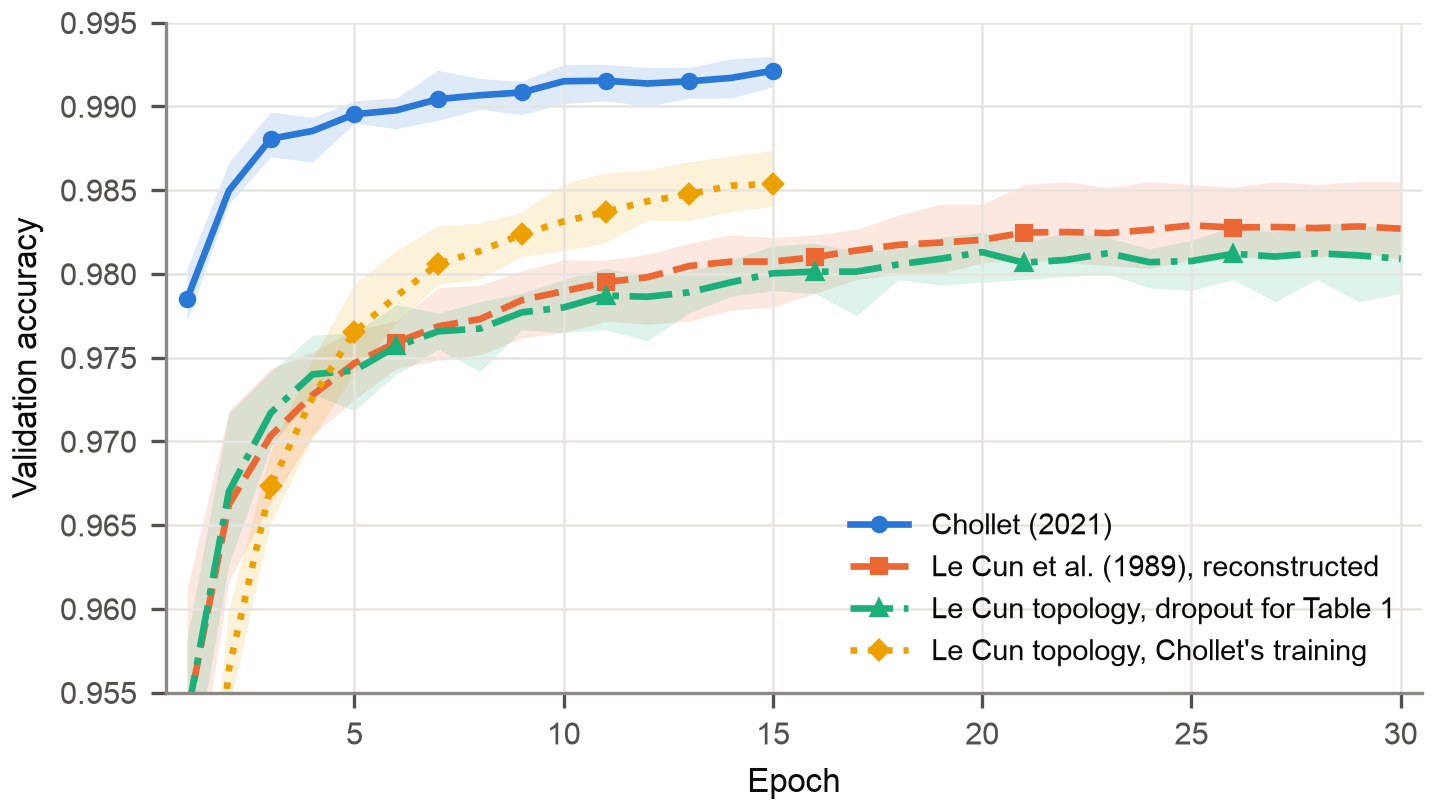

,config,final_train_accuracy,final_val_accuracy,logged_train_accuracy,gap_pp,seeds_train_above_val
0,chollet,0.9955,0.9921,0.9894,0.3363,5
1,lecun,0.9780,0.9827,0.9780,-0.4748,0
2,lecun_dropout,0.9747,0.9809,0.9701,-0.6156,0
3,lecun_chollet_recipe,0.9855,0.9854,0.9846,0.0093,2


In [16]:
curves = {k: np.array([r.history["val_accuracy"] for r in runs[k]]) for k in CONFIGS}
F.save(F.learning_curves(curves, ylim=(0.955, 0.995)), FIG / "fig03_learning_curves.png")
display(Image(FIG / "fig03_learning_curves.png", width=560))

# Training accuracy is measured after training in inference mode (dropout off),
# like validation accuracy. Keras' logged training accuracy is a running mean
# over the last epoch with dropout active, so it is shown only for reference.
final_train_gap = pd.DataFrame({
    "config": list(CONFIGS),
    "final_train_accuracy": [np.mean([r.train_accuracy for r in runs[k]]) for k in CONFIGS],
    "final_val_accuracy": [np.mean([r.history["val_accuracy"][-1] for r in runs[k]]) for k in CONFIGS],
    "logged_train_accuracy": [np.mean([r.history["accuracy"][-1] for r in runs[k]]) for k in CONFIGS],
})
final_train_gap["gap_pp"] = 100 * (final_train_gap["final_train_accuracy"] - final_train_gap["final_val_accuracy"])
final_train_gap["seeds_train_above_val"] = [
    sum(r.train_accuracy > r.history["val_accuracy"][-1] for r in runs[k]) for k in CONFIGS]
final_train_gap.to_csv(TAB / "t09_generalisation_gap.csv", index=False)
display(final_train_gap.round(4))

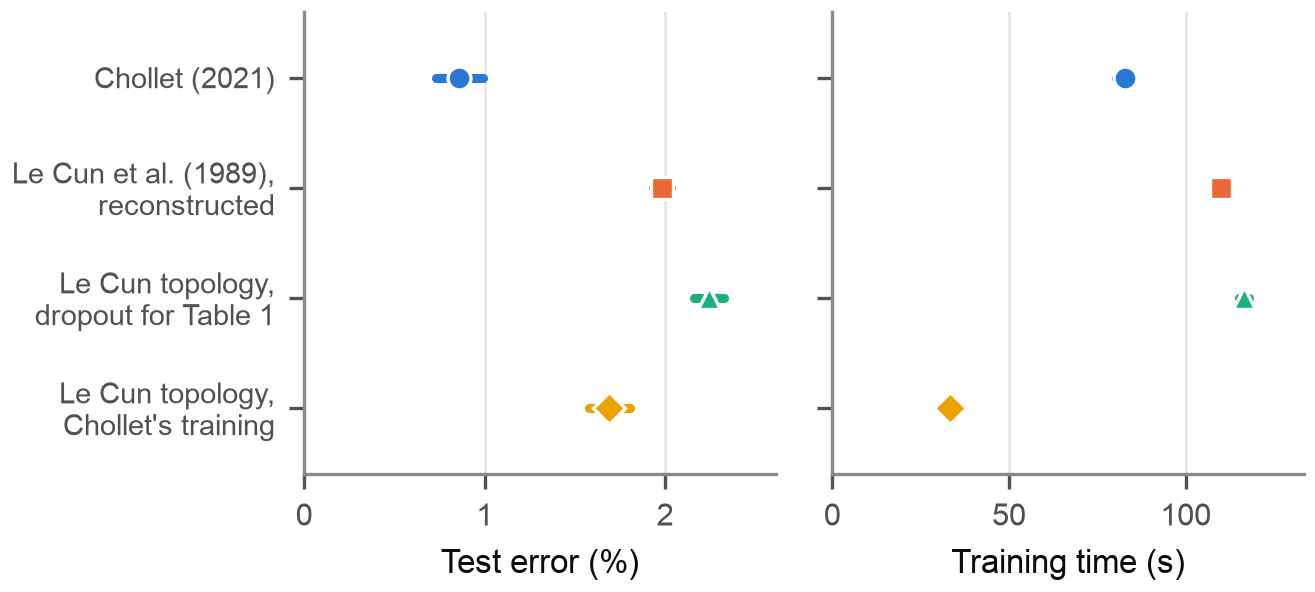

In [17]:
F.save(
    F.metric_dots(summary, list(CONFIGS), [
        ("test_error_pct", "Test error (%)", False),
        ("train_seconds", "Training time (s)", False),
    ]),
    FIG / "fig04_comparison.png",
)
display(Image(FIG / "fig04_comparison.png", width=560))

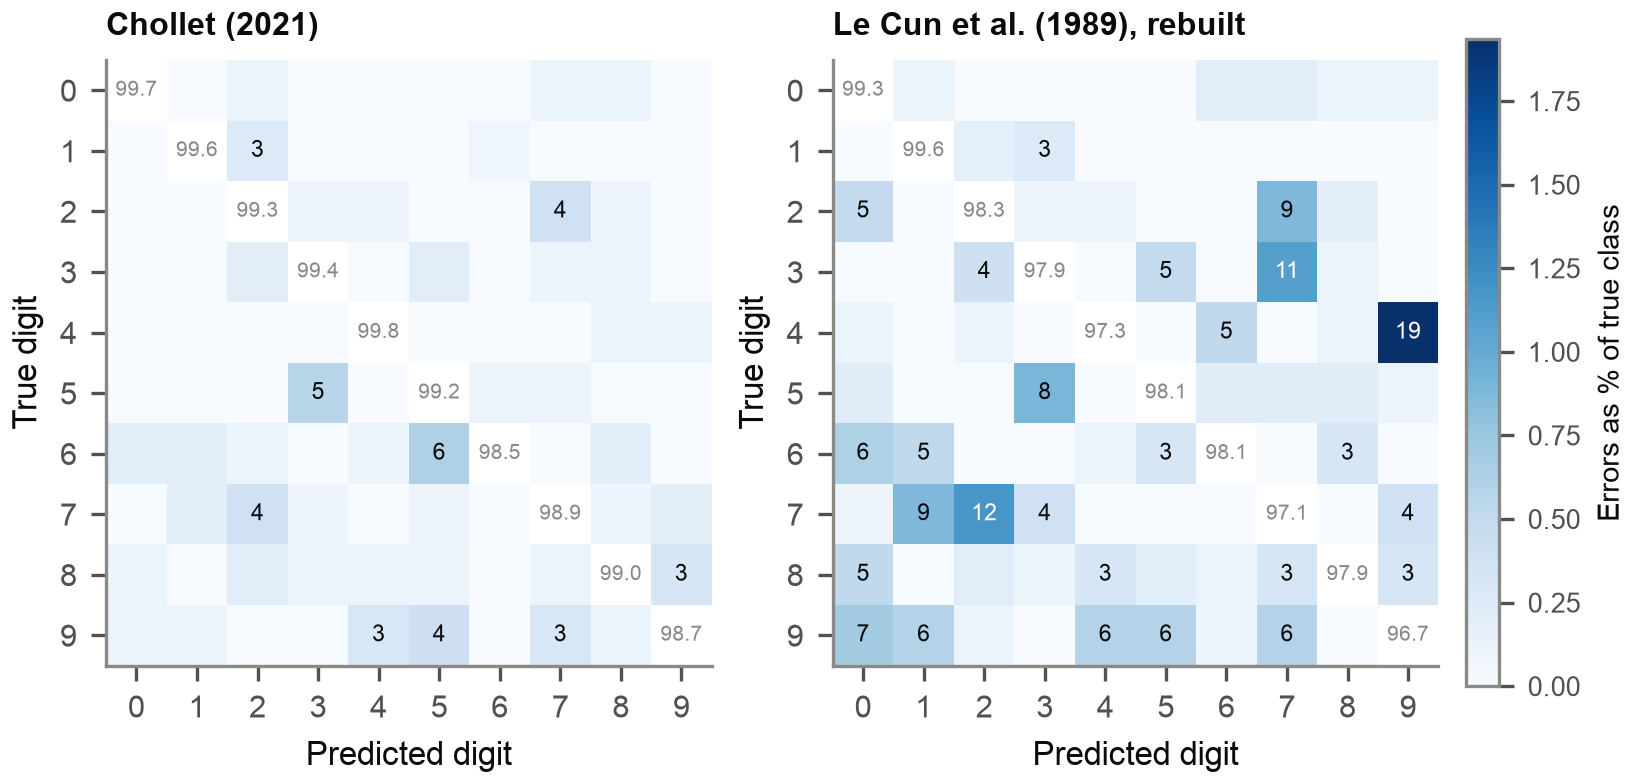

,digit,test_images,chollet_error_pct,lecun_error_pct,lecun_dropout_error_pct,lecun_chollet_recipe_error_pct
0,0,980,0.35,0.47,0.61,0.76
1,1,1135,0.30,0.53,0.58,0.76
2,2,1032,0.93,1.82,2.07,1.49
3,3,1010,0.48,1.82,2.04,1.07
4,4,982,0.43,3.05,3.93,1.51
5,5,892,1.10,2.22,2.40,2.31
6,6,958,1.38,2.03,1.96,1.90
7,7,1028,0.99,2.80,3.58,2.06
8,8,974,1.19,2.53,2.57,2.34
9,9,1009,1.57,2.76,2.87,2.91


chollet  most frequent confusions (seed 0): 6→5 (6), 5→3 (5), 7→2 (4)
lecun    most frequent confusions (seed 0): 4→9 (19), 7→2 (12), 3→7 (11)


In [18]:
# Error analysis on the seed-0 models (the seed shown in the full training logs).
cm = {k: confusion_matrix(y_test, runs[k][0].test_predictions) for k in ("chollet", "lecun")}
F.save(F.confusion_pair(cm, {"chollet": "Chollet (2021)", "lecun": "Le Cun et al. (1989), rebuilt"}),
       FIG / "fig05_confusion.png")
display(Image(FIG / "fig05_confusion.png", width=600))

per_class = pd.DataFrame({
    "digit": range(10),
    "test_images": np.bincount(y_test, minlength=10),
    **{f"{k}_error_pct": [100 * np.mean(np.array([r.test_predictions for r in runs[k]])[:, y_test == d] != d)
                          for d in range(10)] for k in CONFIGS},
})
per_class.to_csv(TAB / "t10_per_class_error.csv", index=False)
display(per_class.round(2))

off = {k: (c - np.diag(np.diag(c))) for k, c in cm.items()}
for k, c in off.items():
    i, j = np.unravel_index(np.argsort(c, axis=None)[::-1][:3], c.shape)
    print(f"{k:<8} most frequent confusions (seed 0): " +
          ", ".join(f"{a}→{b} ({c[a, b]})" for a, b in zip(i, j)))

seed 0: both wrong 44, only 1989 wrong 152, only Chollet wrong 33


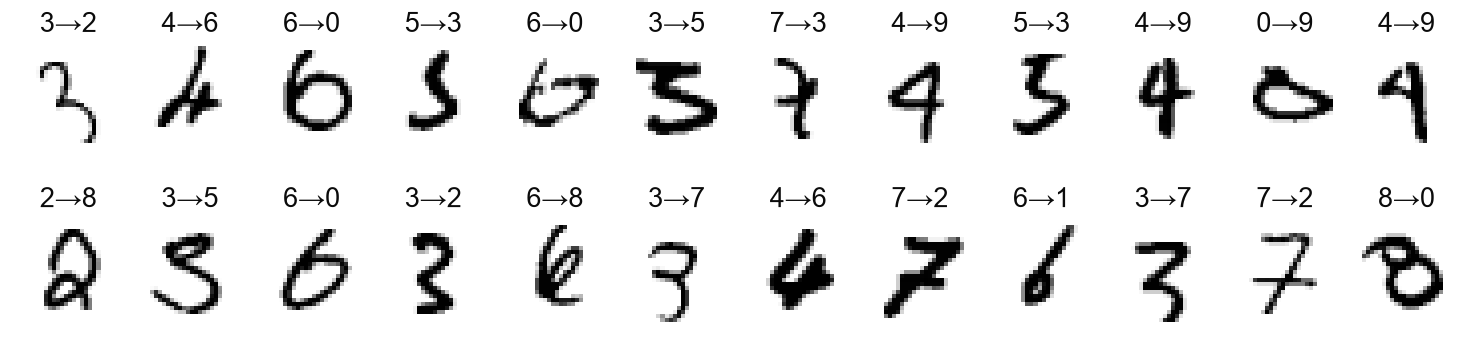

In [19]:
# Which images does the 1989 network get wrong that Chollet's gets right?
lecun_wrong = runs["lecun"][0].test_predictions != y_test
chollet_wrong = runs["chollet"][0].test_predictions != y_test
print(f"seed 0: both wrong {np.sum(lecun_wrong & chollet_wrong)}, only 1989 wrong "
      f"{np.sum(lecun_wrong & ~chollet_wrong)}, only Chollet wrong {np.sum(~lecun_wrong & chollet_wrong)}")
only_lecun = np.flatnonzero(lecun_wrong & ~chollet_wrong)
F.save(F.misclassified_grid(x_test_raw[only_lecun], y_test[only_lecun],
                            runs["lecun"][0].test_predictions[only_lecun], n=24),
       FIG / "fig06_lecun_only_errors.png")
display(Image(FIG / "fig06_lecun_only_errors.png", width=600))

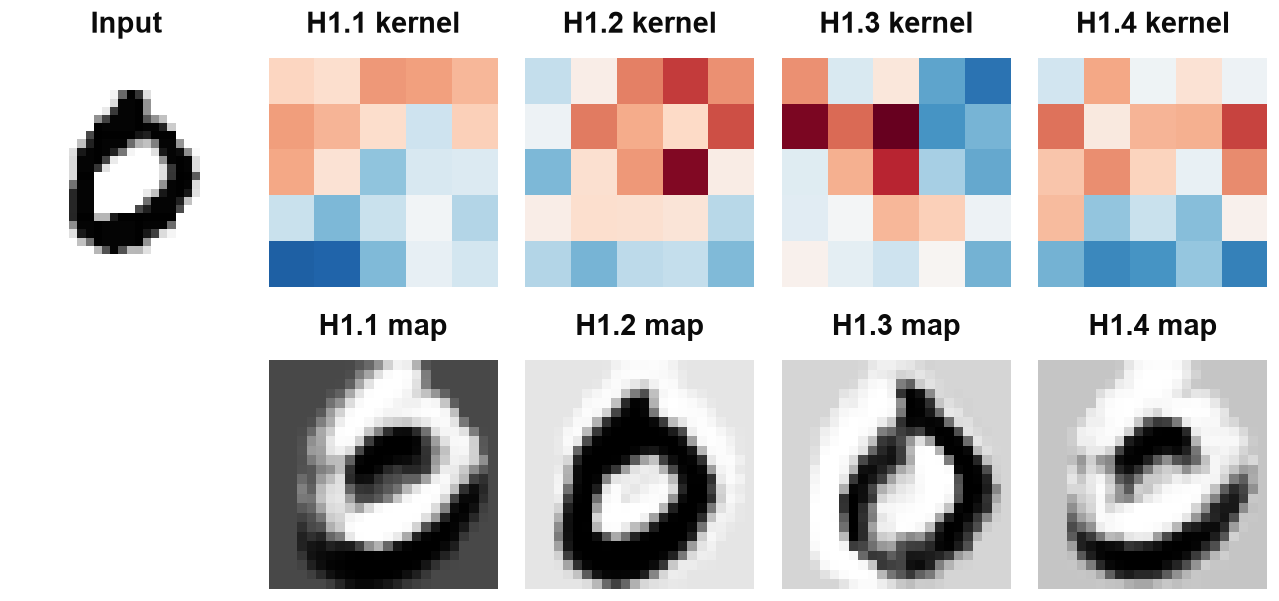

In [20]:
# The learned H1 kernels and their feature maps for one test digit, the view of
# Figure 3 in Le Cun et al. (1989, p. 399).
model = runs["lecun"][0].model
kernels = keras.ops.convert_to_numpy(model.get_layer("H1").kernel)[:, :, 0, :]
probe = keras.Model(model.inputs, model.get_layer("H1").output)
lecun_data = load_mnist("symmetric", "pm1")
digit = int(np.flatnonzero(y_test == 0)[0])
maps = keras.ops.convert_to_numpy(probe(lecun_data.test.x[digit:digit + 1]))[0]
F.save(F.h1_filters_and_maps(kernels, maps, x_test_raw[digit]), FIG / "fig07_h1_filters.png")
display(Image(FIG / "fig07_h1_filters.png", width=540))

## 7 Graphical abstract and export

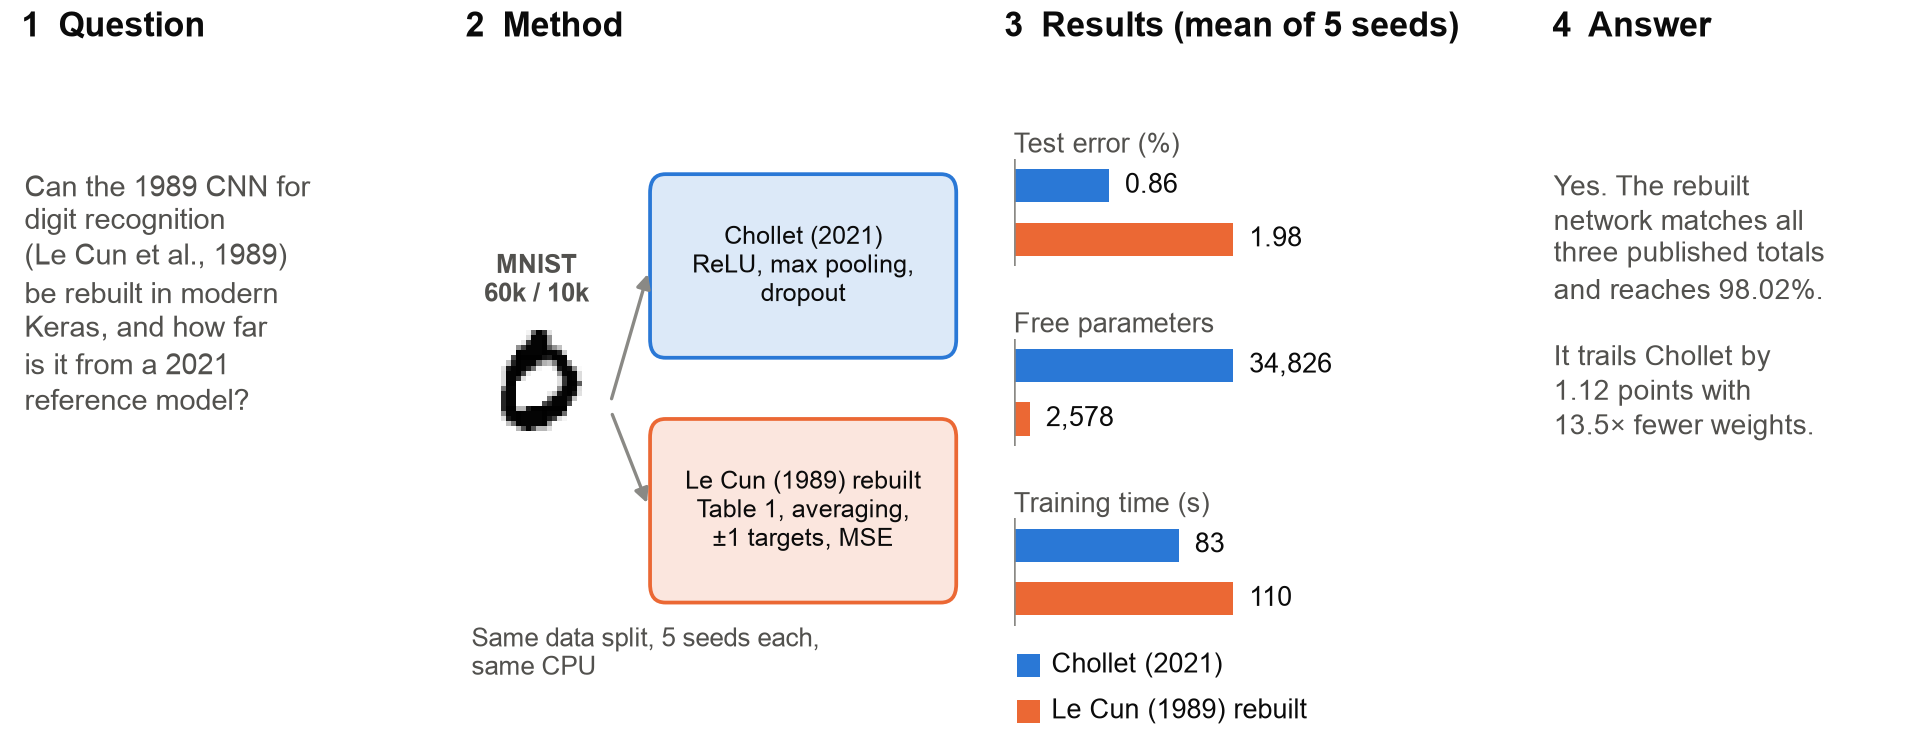

In [21]:
s = summary
delta = s.loc["chollet", "test_accuracy_pct_mean"] - s.loc["lecun", "test_accuracy_pct_mean"]
ratio = s.loc["chollet", "parameters"] / s.loc["lecun", "parameters"]
numbers = {
    "chollet_err": s.loc["chollet", "test_error_pct_mean"],
    "lecun_err": s.loc["lecun", "test_error_pct_mean"],
    "chollet_params": s.loc["chollet", "parameters"],
    "lecun_params": s.loc["lecun", "parameters"],
    "chollet_time": s.loc["chollet", "train_seconds_mean"],
    "lecun_time": s.loc["lecun", "train_seconds_mean"],
    "conclusion": (f"Yes. The rebuilt\nnetwork matches all\nthree published totals\nand reaches "
                   f"{s.loc['lecun', 'test_accuracy_pct_mean']:.2f}%.\n\nIt trails Chollet by\n"
                   f"{delta:.2f} points with\n{ratio:.1f}× fewer weights."),
}
F.save(F.graphical_abstract(x_test_raw[digit], numbers), FIG / "fig00_graphical_abstract.png")
display(Image(FIG / "fig00_graphical_abstract.png", width=640))

In [22]:
# A single machine-readable record of every headline number, so the README and
# any write-up can be checked against what this notebook actually produced.
record = {
    "environment": ENV,
    "seeds": SEEDS,
    "paper_check": check.to_dict(orient="records"),
    "selected_optimiser": best_opt_label,
    "selected_recipe": LECUN_FINAL.to_dict(),
    "selected_dropout": best_drop_label,
    "selection": selection.to_dict(orient="records"),
    "summary": summary.reset_index().to_dict(orient="records"),
    "statistics": stats.to_dict(orient="records"),
}
(MET / "results.json").write_text(json.dumps(record, indent=2, default=float))
print("wrote", (MET / "results.json").relative_to(OUT.parent))
print("tables:", sorted(p.name for p in TAB.glob("*.csv")))
print("figures:", sorted(p.name for p in FIG.glob("*.png")))

wrote results/metrics/results.json
tables: ['t01_class_counts.csv', 't01_partition.csv', 't02_paper_check.csv', 't02_per_layer.csv', 't03_model_selection.csv', 't04_parameters.csv', 't05_all_runs.csv', 't06_summary.csv', 't07_headline.csv', 't08_statistics.csv', 't09_generalisation_gap.csv', 't10_per_class_error.csv']
figures: ['fig00_graphical_abstract.png', 'fig01_mnist_samples.png', 'fig01b_class_distribution.png', 'fig02_architectures.png', 'fig03_learning_curves.png', 'fig04_comparison.png', 'fig05_confusion.png', 'fig06_lecun_only_errors.png', 'fig07_h1_filters.png']
